## Put the TMM codes in the python library folder so they can be imported universally

In [42]:
from phc_codes.TMM import *
from phc_codes.phc_utils import *
from phc_codes.spectra_utils import *
import matplotlib.pyplot as plt
from numpy import linspace, meshgrid, real, array

## Input structure details and wavelength range

In [43]:
# ---------------Data initialization -----------------------------------------
## Refractive indices----------------------------
ni = refractive_index("Quartz_expt")
ns = refractive_index("Quartz_expt")
nh = refractive_index("TiO2_expt")
nl = refractive_index("SiO2_expt")
npva = 1.457 + 0.0002j
nf = 1.0

## Wavelength range ------------------------------
wl_i = 400
wl_f = 800

## Thickness of layers ----------------------------
dpva = 18
dl = 79  # int(real(c_lambda / (4 * nl(c_lambda))))
dl_mod = 120
dh = 46  # int(real(c_lambda / (4 * nh(c_lambda))))
ds = 10

## Arrange the layers ----------------------------
n_bilayer = 8  # total number of bilayers

nn = [ns] + [nh, nl] * n_bilayer +[npva]
N = array(nn, dtype=object)  # R.I. of layers

tt = [ds] + [dh, dl] * (n_bilayer - 1) + [dh, dl_mod, dpva]
T = array(tt)  # thickness of layers


## sample points angles and other parameters ----------
n_lambda = 10000  # no of wavelength samples
n_angle = 50
angle_i = 20
angle_f = 60
Theta_i_deg = linspace(angle_i, angle_f, n_angle)  # angle of incidence(degree)
frac_TE = 1
# ----------------------------------------------------------------------------

In [44]:
# Confirm the structure
print('Thickness ---', T)
print("RI ---")
for ri in N:
    try:
        print(ri(c_lambda))
    except TypeError:
        print(ri,)

Thickness --- [ 10  46  79  46  79  46  79  46  79  46  79  46  79  46  79  46 120  18]
RI ---
(1.4786390025+0j)
(2.403653469+6.155000000000014e-09j)
(1.464495+0.00176j)
(2.403653469+6.155000000000014e-09j)
(1.464495+0.00176j)
(2.403653469+6.155000000000014e-09j)
(1.464495+0.00176j)
(2.403653469+6.155000000000014e-09j)
(1.464495+0.00176j)
(2.403653469+6.155000000000014e-09j)
(1.464495+0.00176j)
(2.403653469+6.155000000000014e-09j)
(1.464495+0.00176j)
(2.403653469+6.155000000000014e-09j)
(1.464495+0.00176j)
(2.403653469+6.155000000000014e-09j)
(1.464495+0.00176j)
(1.457+0.0002j)


## Calculate the necesseries

In [45]:

# Generating data arrays -----------------------------------------------
LAMBDA = generate_lambda(wl_i, wl_f, n_lambda)
Theta_i = (pi / 180) * Theta_i_deg  # in radians

In [46]:
Theta_i = (pi / 180) * Theta_i_deg  # in radians
Reflectance = zeros((n_lambda, n_angle))

# Calculate Transfer Matrix ----------------------------------------
for k, theta_i in enumerate(Theta_i):
    Tr_Matrix = PhCTransferMatrix(LAMBDA, ni, N, nf, T, theta_i, frac_TE)
    Reflectance[:, k] = Tr_Matrix.R

## Plot what needed

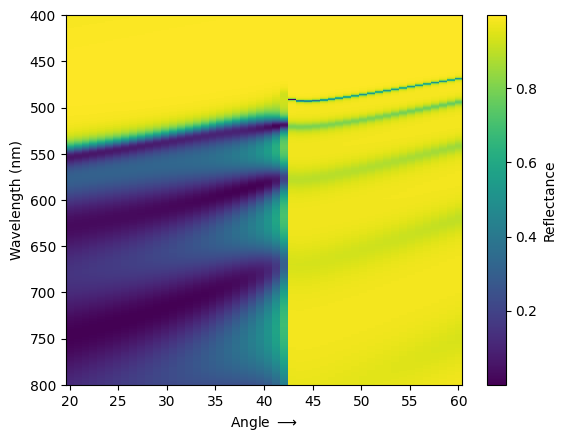

In [47]:

# Plot the disperion ------------------------------------------------------
Th, Lmda = meshgrid(Theta_i_deg, LAMBDA)
plt.pcolormesh(Th, Lmda, Reflectance, lw=1)
plt.colorbar(label="Reflectance")
plt.xlabel(r"Angle $\longrightarrow$")
plt.ylabel(r"Wavelength (nm)")
plt.gca().invert_yaxis()
plt.show()

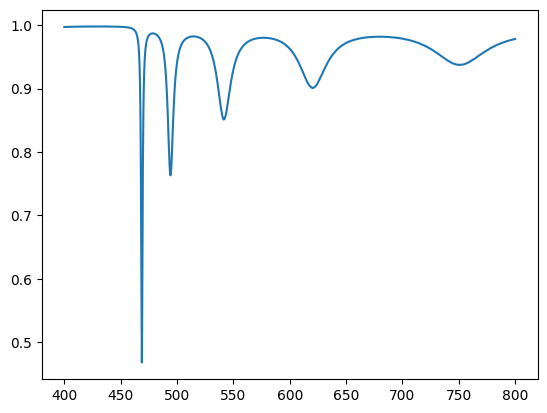

In [48]:
# Plot the data ------------------------------------------------------
fig, ax = plt.subplots()
ax.plot(LAMBDA, Tr_Matrix.R)
plt.show()